<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TimeA015: Attractor Map
Profile     | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude
flat         |       -0.00693 |           0.93732 |             162.54434 |              0.28762
sinusoidal   |       -0.00206 |           0.85869 |             151.77355 |              0.76670
parabolic    |       -0.00381 |           0.91185 |             144.08773 |              0.41785
exponential  |       -0.00335 |           0.90330 |             142.38529 |              0.45554


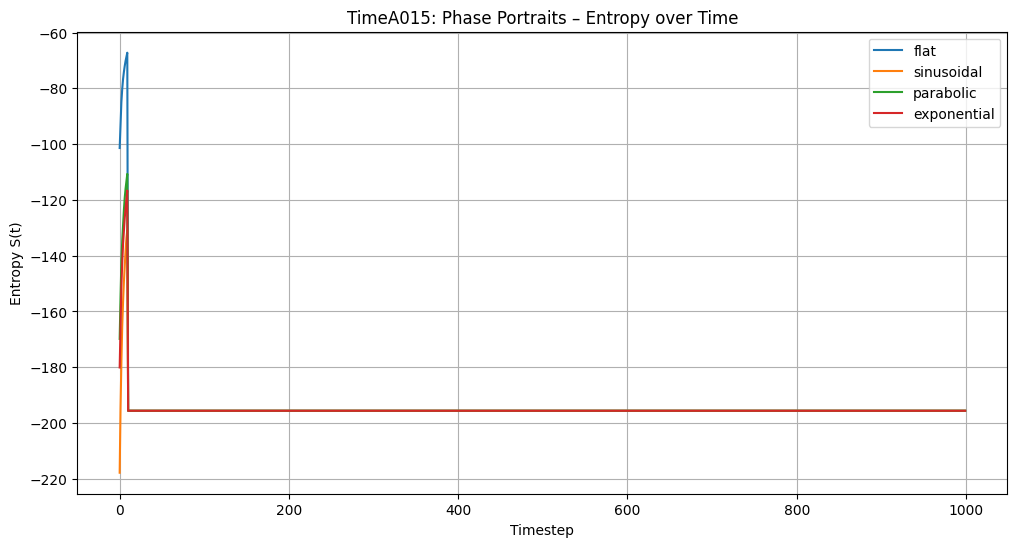

In [ ]:
# 🌀 TimeA015: The Attractor Map
# Long-term resonance behavior under fixed curvature, bias, and feedback
# Author: Chris & Copilot | Arc VI: Resonant Thresholds | ACT032
# Reproducibility Tag: TimeA015_v1

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Parameters ---
N = 100
T = 1000
bias_strength = 0.01
feedback_strength = 0.25
xi_locking = True
curvature_profiles = ['flat', 'sinusoidal', 'parabolic', 'exponential']
seed = 42
np.random.seed(seed)

# --- Curvature Profiles ---
def curvature_profile(profile, N):
    x = np.linspace(-1, 1, N)
    if profile == 'flat':
        return np.zeros((N, N))
    elif profile == 'sinusoidal':
        return np.sin(np.pi * x)[:, None]
    elif profile == 'parabolic':
        return -(x**2)[:, None]
    elif profile == 'exponential':
        return -np.exp(-5 * x**2)[:, None]
    else:
        raise ValueError("Unknown profile")

# --- Initialization ---
def initialize_lattice(N, profile):
    base = np.random.rand(N, N)
    curvature = curvature_profile(profile, N)
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Function ---
def evolve_lattice(lattice, xi_locking, bias_strength, feedback_strength, past_entropy):
    entropy_map = np.gradient(lattice)[0]
    feedback_scalar = feedback_strength * (np.mean(past_entropy) if len(past_entropy) > 0 else 0)
    feedback_field = np.full_like(lattice, feedback_scalar)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map + feedback_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, profile):
    lattice = initialize_lattice(N, profile)
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        past_entropy = np.array(entropy_series[-10:]) if len(entropy_series) >= 10 else np.zeros(10)
        lattice = evolve_lattice(lattice, xi_locking, bias_strength, feedback_strength, past_entropy)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    resonance_amplitude = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, resonance_amplitude

# --- Run Full Scan ---
results = []
trajectories = {}
for profile in curvature_profiles:
    entropy_series, drift = run_simulation(N, T, profile)
    metrics = compute_metrics(entropy_series, drift)
    results.append((profile,) + metrics)
    trajectories[profile] = entropy_series

# --- Output ---
print("TimeA015: Attractor Map")
print("Profile     | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude")
for r in results:
    print(f"{r[0]:<12} | {r[1]:>14.5f} | {r[2]:>17.5f} | {r[3]:>21.5f} | {r[4]:>20.5f}")

# --- Plotting Phase Portraits ---
plt.figure(figsize=(12,6))
for profile in curvature_profiles:
    plt.plot(trajectories[profile], label=profile)
plt.title('TimeA015: Phase Portraits – Entropy over Time')
plt.xlabel('Timestep')
plt.ylabel('Entropy S(t)')
plt.legend()
plt.grid(True)
plt.show()
